<a href="https://colab.research.google.com/github/vikrampal12345/Machine_learning/blob/main/5_Feature_scaling_Normalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Types of Normalization

## 1. MinMaxscaling
## 2. Mean normalization
## 3. Max absolute
## 4. Robust Scaling


In [ ]:
# 1. MinMaxscaling = generally call the normalization

In [ ]:
 import pandas as pd
 import numpy as np
 import seaborn as sns
 import matplotlib.pyplot as plt

 df = pd.read_csv("/content/wine_data.csv", header=None, usecols=[0,1,2])
 df.columns = ['class_label', 'alcohol', 'malic_acid']
 df

,class_label,alcohol,malic_acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   class_label  178 non-null    int64  
 1   alcohol      178 non-null    float64
 2   malic_acid   178 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 4.3 KB


<Axes: xlabel='alcohol', ylabel='Density'>

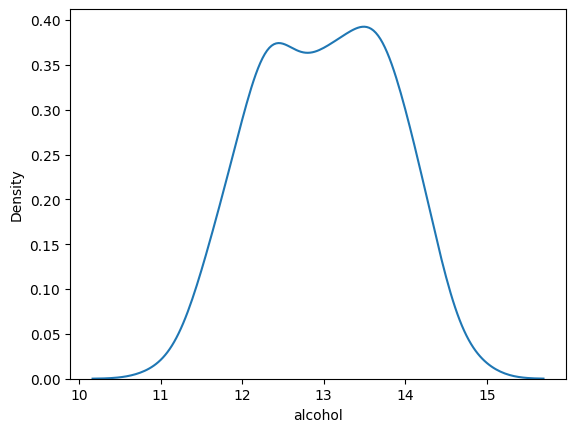

In [ ]:
sns.kdeplot(df['alcohol'])

<Axes: xlabel='malic_acid', ylabel='Density'>

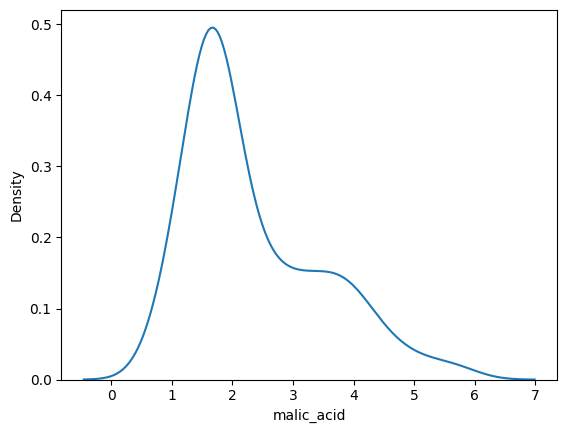

In [ ]:
sns.kdeplot(df['malic_acid'])

<Axes: xlabel='alcohol', ylabel='malic_acid'>

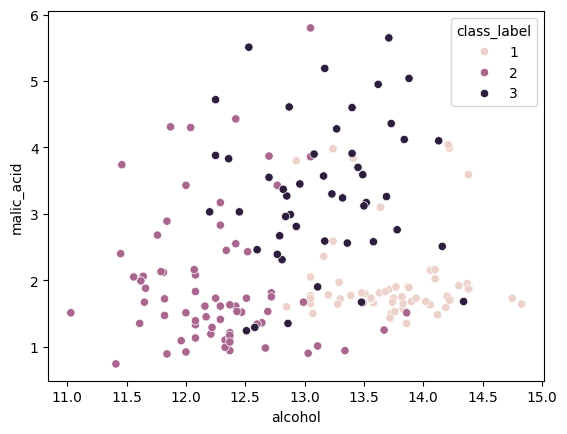

In [ ]:
sns.scatterplot(data=df, x='alcohol', y='malic_acid', hue='class_label')

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(df.drop('class_label', axis=1),
                          df['class_label'], test_size=0.3, random_state=0)

x_train.shape, x_test.shape

((124, 2), (54, 2))

In [ ]:
x_test

In [ ]:
# MinMaxScaling
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(x_train)
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [ ]:
x_train_scaled = pd.DataFrame(x_train_scaled, columns = x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns = x_test.columns)

In [ ]:
x_train_scaled.describe()

,alcohol,malic_acid
count,124.000000,124.000000
mean,0.525017,0.313805
std,0.215414,0.238802
min,0.000000,0.000000
25%,0.358199,0.150735
50%,0.540323,0.209034
75%,0.701613,0.495273
max,1.000000,1.000000


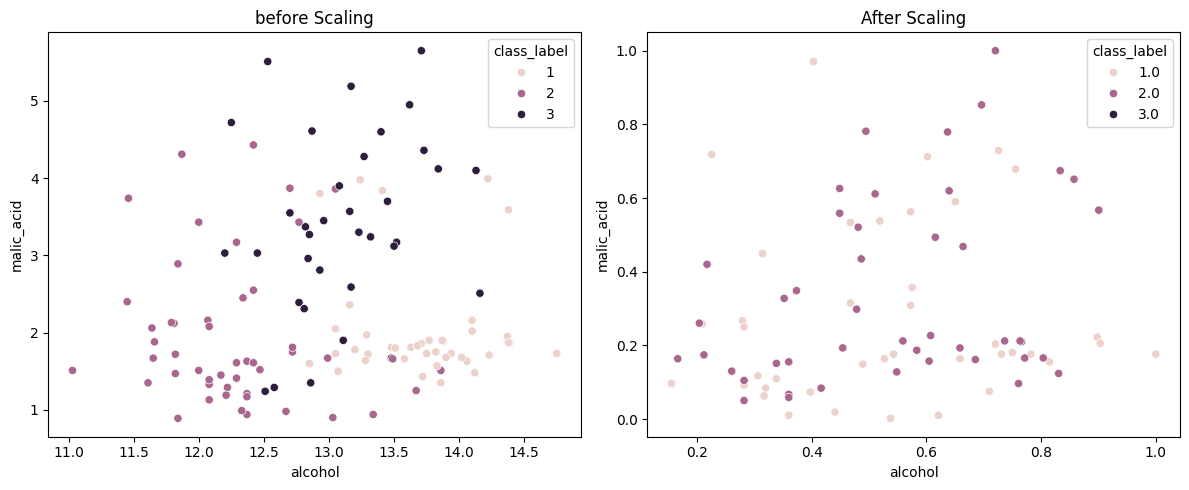

In [ ]:
fig, ax = plt.subplots(1,2 , figsize=(12,5))

sns.scatterplot(data=x_train, x='alcohol',y='malic_acid', ax=ax[0], hue=y_train)
ax[0].set_title("before Scaling")
sns.scatterplot(data=x_train_scaled, x='alcohol',y='malic_acid', ax=ax[1], hue=y_train)
ax[1].set_title("After Scaling")
plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'after scaling')

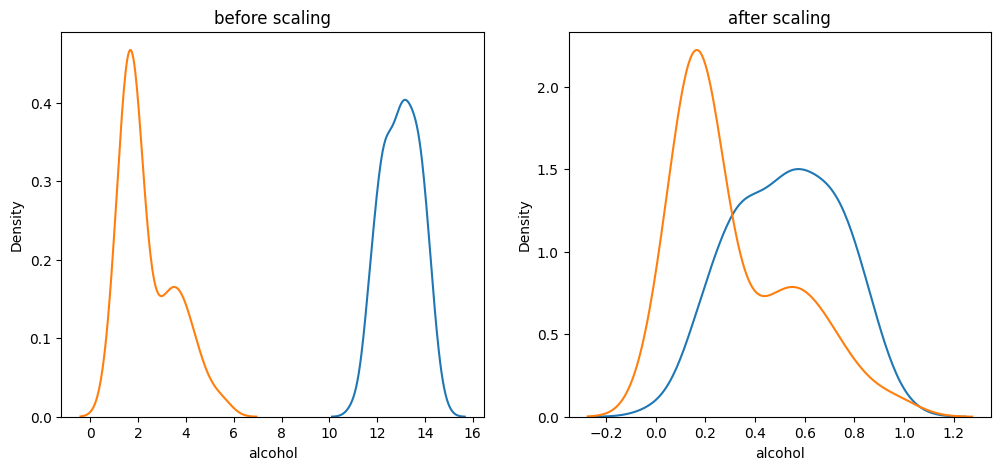

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.kdeplot(x_train['alcohol'], ax=ax[0])
sns.kdeplot(x_train['malic_acid'], ax=ax[0])
ax[0].set_title("before scaling")
sns.kdeplot(x_train_scaled['alcohol'], ax=ax[1])
sns.kdeplot(x_train_scaled['malic_acid'], ax=ax[1])
ax[1].set_title("after scaling")
plt.show()


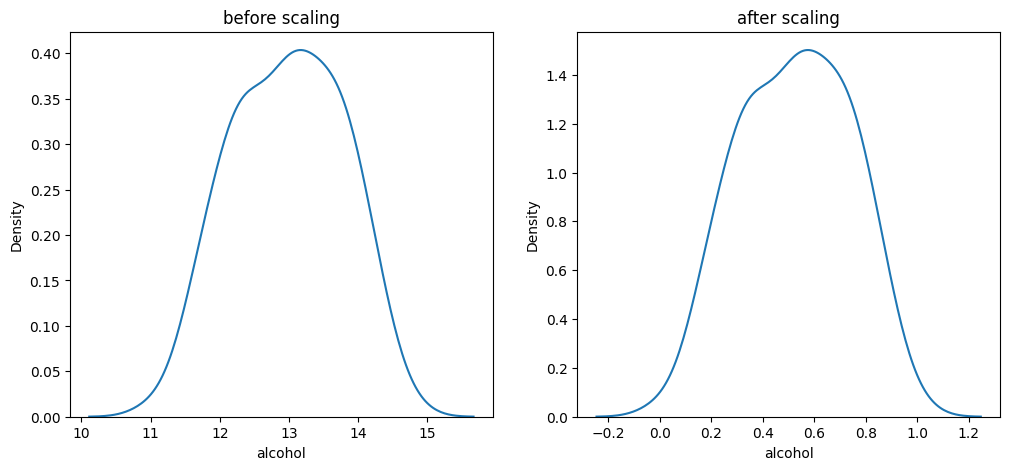

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.kdeplot(x_train['alcohol'], ax=ax[0])

ax[0].set_title("before scaling")
sns.kdeplot(x_train_scaled['alcohol'], ax=ax[1])

ax[1].set_title("after scaling")
plt.show()

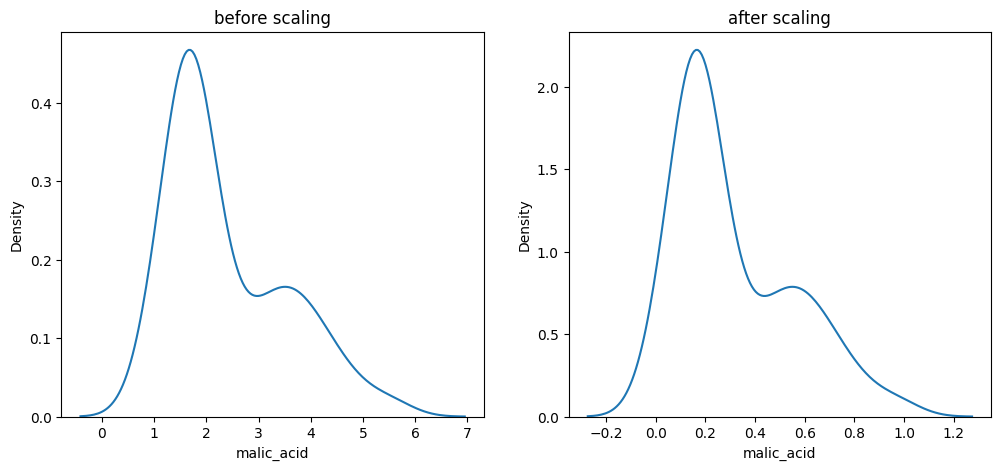

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5))


sns.kdeplot(x_train['malic_acid'], ax=ax[0])
ax[0].set_title("before scaling")

sns.kdeplot(x_train_scaled['malic_acid'], ax=ax[1])
ax[1].set_title("after scaling")
plt.show()

In [ ]:
# sometimes shape while be change